# The GLM, Part 2: Inference  

In this lab we continue our journey with the **General Linear Model (GLM)**, now focusing on **inference** — the statistical tests we use to decide whether estimated parameters (β) provide evidence for an effect in the data.  

> **Key idea**  
> We want to know whether an estimated parameter weight is “large enough” compared to the noise in the data.  
> This is captured by the **t-value**:  
> $$t = \frac{\hat{\beta}}{\text{SE}(\hat{\beta})}$$  
> - **β̂**: estimated parameter  
> - **SE(β̂)**: standard error of that estimate  

This formula is the backbone of most univariate fMRI analyses. Understanding each part of it — and how it relates to your experiment — is crucial for interpreting statistical maps.  

You worked on **estimation** last week: how to fit a GLM and interpret β. This week we take the next step: testing whether those β’s are significantly different from zero. You’ll also practice computing *t*-values and associated *p*-values in Python.  

Note: there are two notebooks this week. Please start with this one, `glm_part2_inference.ipynb`, before moving on to `design_of_experiments.ipynb`.  

**What you’ll learn**  
- Understand the components of the *t*-value formula and how they link to data and design.  
- Calculate *t*-values and corresponding *p*-values from GLM parameters.  
- Interpret statistical results in the context of voxel-wise fMRI analysis.  

**Estimated time to complete:** 1–3 hours  

**Credits:**  
- Originally developed by H. Steven Scholte & Lukas Snoek (2019)  
- Updated by Joe Bathelt (2025)

In [3]:
# First some imports
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv
import os
%matplotlib inline

## Introduction  

From your statistics classes, you may recall that software packages such as **SPSS**, **R**, or **SAS** return not only regression coefficients (β) but also associated *t*-values and *p*-values.  
These statistics allow us to test whether a parameter (or a combination of parameters) is significantly different from zero. In fMRI terms: they tell us whether a voxel shows a reliable activation (or deactivation) in response to one or more experimental factors.  

In **univariate (activation-based) fMRI analysis**, inference requires more than just looking at parameter estimates. We must also take into account the **uncertainty** of those estimates. Simply interpreting the size of a GLM parameter without considering its variability is rarely justified.  

To illustrate this idea, let’s look at a simple example. Suppose we want to predict someone’s **height** (in meters, $\textcolor{blue}{\mathbf{y}}$) from their **weight** (in kilograms, $\textcolor{orange}{\mathbf{X}}$).  

We will fit a linear regression using $\textcolor{orange}{\mathbf{X}}$ (weight) as a predictor of $\textcolor{blue}{\mathbf{y}}$ (height).  
*(Note: the data here is not necessarily representative of the true relationship between height and weight — it’s just for illustration.)*

In [4]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
download_file(
    "https://www.dropbox.com/scl/fi/3zq20t3rqyyaisep0jagw/data_contrast_example.npz?rlkey=pien9uof3wf8mssycmhxys8be&dl=1",
    "data_contrast_example.npz"
)

download_file(
    "https://www.dropbox.com/scl/fi/2ppphyzs9cg3aq0123gi2/weight_height_data.npz?rlkey=3svvikej3dz3l8yvoy8s12rb9&dl=1",
    "weight_height_data.npz"
)

Saved as data_contrast_example.npz


Saved as weight_height_data.npz


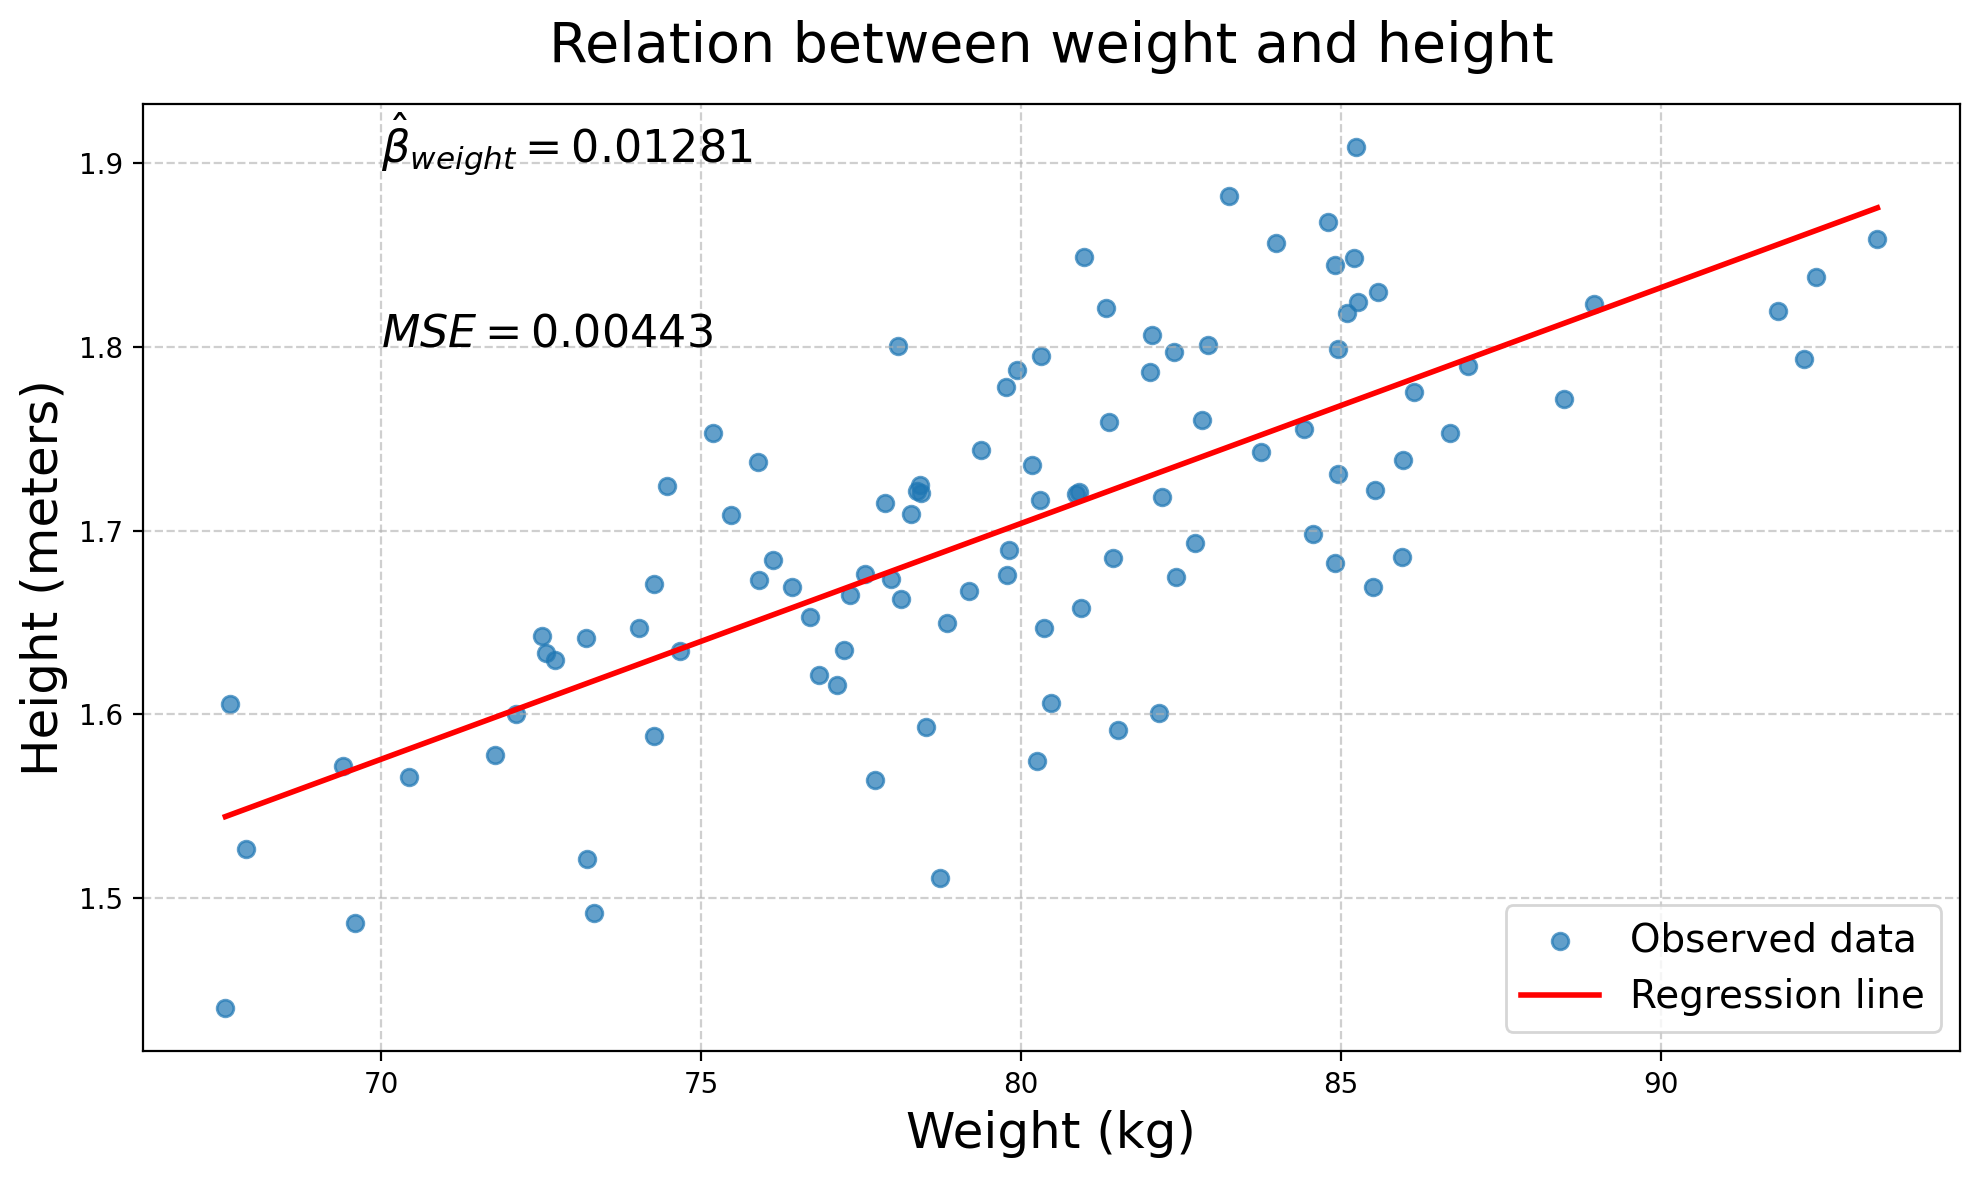

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

# --- Load example data ---
data = np.load("weight_height_data.npz")
X, y = data["X"], data["y"]

# --- Add intercept (column of ones) ---
Xn = np.hstack((np.ones((y.size, 1)), X))

# --- Estimate regression parameters (β) ---
beta = inv(Xn.T @ Xn) @ Xn.T @ y  # [β0, β1]
y_hat = Xn @ beta                 # predicted values

# --- Compute mean squared error (MSE) ---
mse = np.mean((y_hat - y) ** 2)

# --- Plot data and regression line ---
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label="Observed data", alpha=0.7)

# Regression line: compute y for min/max of X
x_line = np.array([X.min(), X.max()])
X_line = np.column_stack((np.ones(2), x_line))
y_line = X_line @ beta
plt.plot(x_line, y_line, color="red", lw=2, label="Regression line")

# Labels and title
plt.title("Relation between weight and height", fontsize=20, pad=15)
plt.xlabel("Weight (kg)", fontsize=18)
plt.ylabel("Height (meters)", fontsize=18)

# Display parameter and error info
plt.text(70, 1.9, rf"$\hat{{\beta}}_{{weight}} = {float(beta[1]):.5f}$", fontsize=16)
plt.text(70, 1.8, rf"$MSE = {mse:.5f}$", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=14, loc='lower right')
plt.tight_layout()
plt.show()

At first glance, the estimated $\hat{\beta}$ might look “small”. But notice that the **scale of β depends on how we measure our data**.  

To illustrate, let’s change our outcome variable: instead of predicting **height in meters** ($\textcolor{blue}{y}$), we’ll predict **height in centimeters**.  
This is simply a rescaling of the same data:  
$$\textcolor{blue}{y}_{cm} = 100 \times \textcolor{blue}{y}_{m}$$  

The relationship between weight and height hasn’t changed — but the numerical value of $\hat{\beta}$ will look very different.  

In [6]:
y_cm = y * 100

At first sight, you might expect that rescaling the outcome variable (from meters to centimeters) would not change the **model itself** — after all, the relationship between weight and height hasn’t changed.  

But as you’ll see below, the **numerical value of the parameter estimate** changes a lot. This illustrates why interpreting *raw* β-values can be misleading without considering scale and uncertainty.

<div class='alert alert-warning'>  
<b>ToDo</b> (0 points):  
    Repeat the linear regression from the previous code block, but this time use <tt>y_cm</tt> (height in <b>centimeters</b>) instead of <tt>y</tt> (height in <b>meters</b>) as the target variable.  

You can reuse the same design matrix <tt>Xn</tt>.  

- Estimate the regression parameters and store them in <tt>beta_cm</tt>.  
- Compute the mean squared error and store it in <tt>mse_cm</tt>.  

</div>  

<details open>
  <summary>💡 Solution (click to expand)</summary>

```python
# --- Fit regression with y in centimeters ---
beta_cm = inv(Xn.T @ Xn) @ Xn.T @ y_cm
y_hat_cm = Xn @ beta_cm

# --- Compute MSE ---
mse_cm = np.mean((y_hat_cm - y_cm) ** 2)

print("β (centimeters):", beta_cm)
print("MSE (centimeters):", mse_cm)
```

Notice how the **numerical value of β** changes drastically after rescaling $ \textcolor{blue}{y} $, 
even though the underlying relationship between weight and height has not.

This is why we need to move from **raw β’s** to **standardised statistics (t-values)** for inference.

</details>



If you did this correctly, you should find that the β-parameter in the **centimeters model** is exactly **100 times larger** than in the **meters model**.  

This illustrates an important point: the *raw* value of β depends entirely on the **scale of your variables**.  

Rescaling either $\textcolor{orange}{\mathbf{X}}$ or $\textcolor{blue}{\mathbf{y}}$ will directly change the numerical value of the estimated $\textcolor{darkred}{\beta}$ — even though the underlying relationship between predictor and outcome has not changed.

<div class='alert alert-info'>  
<b>ToThink</b> (0 points):  
Notice that the MSE in the model with <tt>y_cm</tt> (height in centimeters) is <b>10,000 times larger</b> than in the model with <tt>y</tt> (height in meters).  

Why does rescaling the outcome variable by a factor of 100 lead to such a large change in the MSE?  
</div>  

<details>  
<summary><b>💡 Explanation</b> (click to expand)</summary>  

The mean squared error (MSE) is defined as:  

$$
MSE = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2
$$  

If we multiply $\textcolor{blue}{y}$ by 100 (meters → centimeters), the prediction errors $(y - \hat{y})$ are also multiplied by 100.  

Since MSE squares these errors, the scaling factor becomes:  

$$
(100 \cdot \text{error})^2 = 100^2 \cdot (\text{error}^2) = 10{,}000 \cdot (\text{error}^2).
$$  

Therefore, the MSE increases by a factor of $100^2 = 10{,}000$.  
</details>  

<div class='alert alert-info'>  
<b>ToThink</b> (2 points):  
You’ve seen that the scale of the data (whether in $\textcolor{orange}{X}$ or $\textcolor{blue}{y}$) directly affects the size of the raw parameter estimates.  

At first glance, you might think this isn’t an issue for fMRI, since all voxels measure the same type of BOLD signal.  
But this assumption is **incorrect** — voxel signals can differ in scale for several reasons.  

👉 Write down at least **two reasons** why different voxels might show different signal scales.  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>

Different voxels might show different signal scales due to these reasons: 

1. Different tissues have different proton densities \(e.g., white matter, grey matter, CSF\) and may therefore emit signals of varying intensities. 
2. Signals measured from the same voxels on different occasions may also be influenced by non\-neuronal activity, such as variations in blood flow due to the physiological state of the participant. As a result, signal intensities might differ. Thus, all signals from voxels may not be comparable at an absolute scale. 



## How to compute *t*-values and *p*-values  

So far, we’ve seen that interpreting raw $\textcolor{darkred}{\beta}$-parameters is problematic because their value depends heavily on the **scale** of the variables.  

But how, then, can we meaningfully interpret the effect of a predictor on our outcome variable?  

The answer lies in comparing the **signal** (the estimated effect) to the **noise** (the uncertainty of that estimate). Importantly, both the $\textcolor{darkred}{\beta}$-values and the residual errors (MSE) depend on the scale of the data — so we need a statistic that accounts for both.  

---

### *t*-values  

The key idea is to **standardise** an estimated $\hat{\textcolor{darkred}{\beta}}$ by dividing it by its **standard error**, denoted $\mathrm{SE}_{\hat{\beta}}$.  
The standard error is the square root of the variance of the parameter estimate:  

\begin{align}
t_{\hat{\beta}} = \frac{\hat{\beta}}{\mathrm{SE}(\hat{\beta})} 
= \frac{\hat{\beta}}{\sqrt{\mathrm{Var}(\hat{\beta})}}
\end{align}  

This gives us a unitless test statistic — the familiar *t*-value — that tells us whether an effect is large relative to its uncertainty.  

<div class='alert alert-info'>  
<b>ToThink</b> (0 points):  
Suppose you know the standard error ($\mathrm{SE}$) of a particular $\hat{\textcolor{darkred}{\beta}}$.  
    How can you derive the <b>variance</b> of that parameter estimate from its standard error?  

*(Hint: the answer is as straightforward as you think.)*  
</div>  

<details>  
<summary><b>💡 Solution</b> (click to expand)</summary>  

By definition:  

$$
\mathrm{SE}(\hat{\beta}) = \sqrt{\mathrm{Var}(\hat{\beta})}
$$  

So if we know the standard error, we obtain the variance simply by squaring it:  

$$
\mathrm{Var}(\hat{\beta}) = \big(\mathrm{SE}(\hat{\beta})\big)^2
$$  
</details> 

Another useful perspective is that the *t*-value is the **effect** ($\hat{\textcolor{darkred}{\beta}}$) divided by your **uncertainty** about that effect ($\mathrm{SE}(\hat{\beta})$). In other words, *t*-values are **uncertainty-normalised effects**.

So what drives statistical uncertainty in $\hat{\textcolor{darkred}{\beta}}$?  

To answer this, let’s unpack the standard error, $\mathrm{SE}(\hat{\beta})$. Conceptually, it reflects two ingredients:

- the **unexplained variance** of the model (the *noise* in $\textcolor{blue}{y}$), and  
- the **design variance** (uncertainty induced by the design, i.e., properties of $\textcolor{orange}{\mathbf{X}}$).

In this lab we will **treat the design variance as given by the design matrix** $\textcolor{orange}{\mathbf{X}}$ (we’ll dig into it in the companion notebook `design_of_experiments.ipynb`). With that in mind, a helpful conceptual form is:

$$
\mathrm{SE}(\hat{\beta}) \;=\; \sqrt{\;\underbrace{\text{noise}}_{\hat{\sigma}^2}\;\times\;\underbrace{\text{design variance}}_{\text{depends on }\textcolor{orange}{\mathbf{X}}}\;}
$$


This leads to a corresponding conceptual form of the *t*-statistic:

$$
t_{\hat{\beta}} \;=\; \frac{\hat{\beta}}{\mathrm{SE}(\hat{\beta})}
\;=\;
\frac{\;\underbrace{\text{effect}}_{\hat{\textcolor{darkred}{\beta}}}\;}
{\sqrt{\;\underbrace{\text{noise}}_{\hat{\sigma}^2}\;\times\;\underbrace{\text{design variance}}_{\text{depends on }\textcolor{orange}{\mathbf{X}}}\;}}
$$

**This “effect ÷ (noise × design)” view is central to the course.**  

In GLM-based fMRI, the *t*-value you observe depends on (i) the estimated effect $\hat{\textcolor{darkred}{\beta}}$ and (ii) its uncertainty, where the latter decomposes into **noise** (unexplained variance in $\textcolor{blue}{y}$) and **design variance** (how well the design allows that effect to be estimated).

- In `design_of_experiments.ipynb` (this week), we’ll see how good design can **reduce design variance**.  
- In next week’s **preprocessing** notebook, we’ll see how denoising steps can **reduce the noise** term.

For now, we’ll learn how to **estimate the noise term**. It is closely related to the MSE: instead of the mean of squared residuals, we use the **sum of squared residuals** (SSE) divided by the model’s **degrees of freedom**:

$$
\hat{\sigma}^{2}
\;=\;
\frac{\sum_{i=1}^{N}\big(y_i - \hat{y}_i\big)^2}{\mathrm{df}},
\qquad
\mathrm{df} \;=\; N - P
$$


where \(N\) is the number of observations and \(P\) is the number of predictors **including the intercept**.

Putting this together, the *t*-statistic for a parameter becomes:

$$
t_{\hat{\beta}}
\;=\;
\frac{\hat{\beta}}
{\sqrt{\;\dfrac{\sum_{i=1}^{N}\big(y_i - \hat{y}_i\big)^2}{\,N - P\,}\;\times\;\text{design variance}}}
$$

<div class='alert alert-info'>  
<b>ToThink</b> (0 points):  
    We just saw that <i>t</i>-values are “uncertainty-normalised” effects. Let’s test that idea.  

Suppose we fit two models:  

- Model A: predict height in **meters** from weight  
- Model B: predict height in **centimeters** from weight  

From earlier, you know that the $\hat{\textcolor{darkred}{\beta}}$ for Model B will be exactly **100 times larger** than for Model A.  

👉 Based on the formula for the *t*-statistic, what do you expect for the *t*-values of the weight predictor in the two models? Will they:  
1. also differ by a factor of 100,  
2. be 10,000 times larger in the centimeter model, or  
3. be the same?  

Write down your reasoning before checking with Python in the next step.  
</div>  

<details>  
<summary><b>💡 Explanation</b> (click to expand)</summary>  

- Rescaling $\textcolor{blue}{y}$ by 100 scales the effect estimate $\hat{\textcolor{darkred}{\beta}}$ by 100.  
- But the **noise term** (residual variance, $\hat{\sigma}^2$) is also scaled by 100² = 10,000.  
- Since the *t*-value divides β by its standard error (which grows by a factor of 100), the scaling cancels out.  

Therefore, the *t*-values are the **same** in both models.  

This shows why *t*-statistics (and *p*-values) are meaningful: they let us compare effects across different scales of measurement.  
</details>  

Alright — enough formulas. Let’s compute these pieces in Python.  


We’ll compare the *t*-statistic for the weight predictor in the **meters** and **centimeters** models to show that converting to *t*-values **normalises** the raw $\hat{\textcolor{darkred}{\beta}}$’s.  
We’ll provide a small helper to compute the **design variance** for you; you **don’t** need to understand its internals yet (we’ll explain it in `design_of_experiments.ipynb`).

In [7]:
def design_variance(X, which_predictor=1):
    """
    Compute the design variance for a given predictor or contrast vector.

    Parameters
    ----------
    X : numpy.ndarray
        Design matrix of shape (N, P), where N = number of samples
        and P = number of predictors (including intercept).
    which_predictor : int or array-like
        - If int: index of the predictor to evaluate (0 = intercept).
        - If array-like: a contrast vector of length P.

    Returns
    -------
    des_var : float
        The design variance of the specified predictor or contrast.
    """

    # Case 1: single predictor index
    if isinstance(which_predictor, int):
        c = np.zeros(X.shape[1])
        c[which_predictor] = 1

    # Case 2: full contrast vector
    else:
        c = np.asarray(which_predictor)
        if c.shape[0] != X.shape[1]:
            raise ValueError("Contrast vector length must match number of predictors (columns of X).")

    # Compute design variance: cᵀ (XᵀX)⁻¹ c
    XtX_inv = np.linalg.inv(X.T @ X)
    des_var = float(c @ XtX_inv @ c.T)

    return des_var

So, if we want to compute the **design variance** of the *weight* predictor in our design matrix `Xn` (from earlier), we can simply call:

In [8]:
# The weight predictor is in column index 1 of Xn 
# (recall: index 0 = intercept, index 1 = weight)
design_variance_weight = design_variance(Xn, which_predictor=1)

print(f"Design variance of the weight predictor: {design_variance_weight:.6f}")

Design variance of the weight predictor: 0.000334


Alright — the last ingredient we need is the **noise term** ($\hat{\sigma}^2$):  

In [9]:
# --- Refit the linear regression (meters model) for clarity ---
beta_meter = inv(Xn.T @ Xn) @ Xn.T @ y
y_hat_meter = Xn @ beta_meter

# --- Degrees of freedom ---
N = y.size              # number of observations
P = Xn.shape[1]         # number of predictors (incl. intercept)
df = N - P
print(f"Degrees of freedom: {df}")

# --- Estimate noise term (σ²) ---
sigma_hat = np.sum((y - y_hat_meter) ** 2) / df
print(f"Estimated noise (σ²): {sigma_hat:.3f}")

# --- Design variance for the weight predictor ---
design_variance_weight = design_variance(Xn, which_predictor=1)
print(f"Design variance of weight predictor: {design_variance_weight:.6f}")

Degrees of freedom: 98
Estimated noise (σ²): 0.005
Design variance of weight predictor: 0.000334


Now we can calculate the *t*-value:

In [10]:
# --- Compute t-value for the weight predictor ---
t_meter = beta_meter[1] / np.sqrt(sigma_hat * design_variance_weight)

print(f"The t-value for the weight predictor "
      f"(β = {beta_meter[1][0]:.3f}) is: {t_meter[0]:.3f}")

The t-value for the weight predictor (β = 0.013) is: 10.431


That’s it! You’ve now seen all the steps for calculating a *t*-value in linear regression. 

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  
    Calculate the <i>t</i>-statistic for the weight predictor in the <b>centimeter model</b> you fitted earlier.  

- Store the result in a variable called <tt>t_centimeter</tt>.  
- You do **not** need to recompute the design variance (since <tt>X</tt> hasn’t changed) — just reuse <tt>design_variance_weight</tt>.  
</div>

In [11]:
''' Implement your ToDo here. '''

# YOUR CODE HERE
Xn = np.hstack((np.ones((y_cm.size, 1)), X))

# calulating beta, y hat and mse in cm
beta_cm = inv(Xn.T @ Xn) @ Xn.T @ y_cm 
y_hat_cm = Xn @ beta_cm
mse_cm = np.mean((y_hat_cm - y) ** 2)

# listing parameters and calculating sigma hat in cm
N = y_cm.size
P = Xn.shape[1]
df = (N - P)
sigma_hat_cm = np.sum((y_cm - y_hat_cm) ** 2) / df

# calculating t statistic
t_centimeter = beta_cm[1] / np.sqrt(sigma_hat_cm * design_variance_weight)
# raise NotImplementedError()

print("The t-value for the weight predictor in cm model (beta = %.3f) is: t=%.3f(%.f)" % (beta_cm[1], t_centimeter, df))

The t-value for the weight predictor in cm model (beta = 1.281) is: t=10.431(98)


In [12]:
# Feedback cell
if "t_centimeter" not in locals():
    print('The variable "t_centimeter" is not defined.')
elif not (np.isscalar(t_centimeter) or (isinstance(t_centimeter, np.ndarray) and t_centimeter.size == 1)):
    print('"t_centimeter" should be a single numeric value.')
else:
    value = float(t_centimeter) if np.isscalar(t_centimeter) else float(t_centimeter.item())
    if np.isnan(value) or np.isinf(value):
        print('Your t-value is NaN or infinite. Check your calculation.')
    elif value < 0:
        print('Note: Your t-value is negative. Does that make sense given the relationship between height and weight?')
    elif value < 2:
        print('Note: Your t-value is quite small. In this dataset, weight is a strong predictor of height.')
    else:
        print('Your t-v looks reasonable.')

Your t-v looks reasonable.


### *p*-values  

By now, you’ve seen how calculating *t*-values solves the problem of uninterpretable raw $\hat{\textcolor{darkred}{\beta}}$’s.  
The next step is to ask: **how likely is it to observe a *t*-value this extreme if the true effect were zero?**  
That probability is what we call the *p*-value.  

You may recall that a *p*-value corresponds to the area under the curve of a *t*-distribution beyond your observed statistic (and more extreme values):  


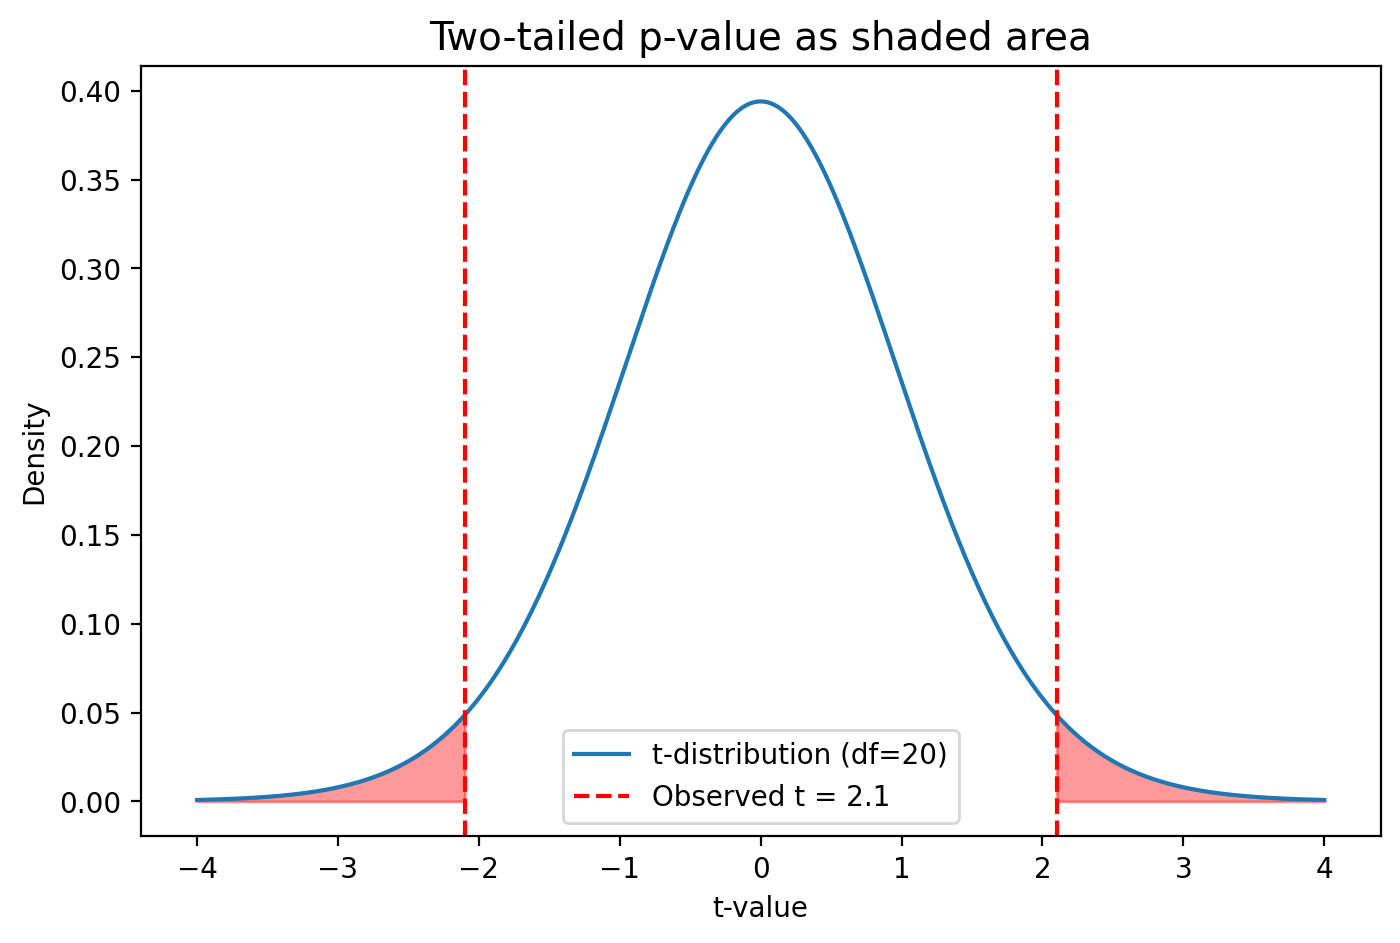

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# Parameters
df = 20
t_obs = 2.1
x = np.linspace(-4, 4, 500)
y = t.pdf(x, df)

# Plot distribution
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f"t-distribution (df={df})")

# Shade two-tailed p-value region
x_tail_right = np.linspace(t_obs, 4, 200)
plt.fill_between(x_tail_right, t.pdf(x_tail_right, df), alpha=0.4, color="red")

x_tail_left = np.linspace(-4, -t_obs, 200)
plt.fill_between(x_tail_left, t.pdf(x_tail_left, df), alpha=0.4, color="red")

# Annotate
plt.axvline(t_obs, color="red", linestyle="--", label=f"Observed t = {t_obs}")
plt.axvline(-t_obs, color="red", linestyle="--")
plt.title("Two-tailed p-value as shaded area", fontsize=14)
plt.xlabel("t-value")
plt.ylabel("Density")
plt.legend()
plt.show()

In Python, the function `stats.t.sf(t_value, df)` from `scipy.stats` computes exactly this “tail area.” 

A few important points:  

- `stats.t.sf()` always returns the **right-tailed p-value**.  
- To handle both positive and negative *t*-values, use the absolute value: `np.abs(t_value)`.  
- By default, this gives a **one-sided p-value**.  
- For a **two-sided test** (the usual case in fMRI), simply multiply by 2.  

---

👉 Let’s put this into practice:  

In [14]:
from scipy import stats

# --- Compute two-tailed p-value from t-statistic ---
# Use absolute value to handle both positive and negative t-values
p_value = stats.t.sf(np.abs(t_meter), df) * 2  

print(f"The p-value corresponding to t({df}) = {t_meter[0]:.3f} is: {p_value[0]:.8f}")

The p-value corresponding to t(20) = 10.431 is: 0.00000000


## Contrasts  

We’re almost there — you now know about 99% of what you need for the GLM in fMRI (apart from some caveats about GLM assumptions, which we’ll cover next week). 

The final major concept is **contrasts**.  

Contrasts are follow-up statistical tests on the estimated GLM parameters. With them, you can implement essentially any (linear) statistical test you know from statistics: *t*-tests, *F*-tests, AN(C)OVAs — all can be expressed as contrasts within the GLM framework.  

> **Key idea**  
> A contrast encodes your **hypothesis** about the parameters ($\textcolor{darkred}{\beta}$’s) in the design matrix.  

If you’d like to explore this connection further, see this excellent overview: [*Common statistical tests are linear models*](https://lindeloev.github.io/tests-as-linear/).  

---

### *t*-tests  

In the GLM, *t*-tests can be set up in two common ways:  

**1. Testing a parameter against baseline**  
This asks whether a single predictor has *any* effect on the dependent variable.  

- $H_{0}: \;\beta = 0$ (null hypothesis: no effect)  
- $H_{a}: \;\beta \neq 0$ (two-sided alternative: some effect)  

Directional alternatives are also possible:  
- $H_{a}: \;\beta > 0$ (positive effect)  
- $H_{a}: \;\beta < 0$ (negative effect)  

---

**2. Comparing two parameters**  
This asks whether one predictor has a larger effect than another.  

- $H_{0}: \;\beta_{1} - \beta_{2} = 0$ (no difference)  
- $H_{a}: \;\beta_{1} - \beta_{2} \neq 0$ (some difference)  

---

### Example: testing one condition effect  

Suppose we run an fMRI experiment with six conditions:  

1. Male faces – happy expression  
2. Male faces – sad expression  
3. Male faces – neutral expression  
4. Female faces – happy expression  
5. Female faces – sad expression  
6. Female faces – neutral expression  

Let’s assume we have 100 volumes of fMRI data. After convolution with a canonical HRF, the design matrix has shape $(100 \times 7)$:  
- 1 column for the intercept  
- 6 columns for the conditions  

Our target signal (voxel time series) has shape $(100,)$.  

We’ll now load in this data and see how to test a simple hypothesis using a contrast: *does one condition (e.g. happy male faces) show an effect on the BOLD response?*  

In [15]:
# --- Load example data for contrasts ---
data = np.load("data_contrast_example.npz")
X, y = data["X"], data["y"]

print(f"Design matrix shape (X): {X.shape}")   # (100, 7)
print(f"Target signal shape (y): {y.shape}")  # (100,)

Design matrix shape (X): (100, 7)
Target signal shape (y): (100,)


After fitting a GLM with these 6 predictors (each convolved with a canonical HRF) plus an intercept,  
we obtain **7 parameter estimates ($\hat{\textcolor{darkred}{\beta}}$’s)** — one for each column of the design matrix:

In [16]:
# --- Estimate beta parameters (ordinary least squares) ---
betas = inv(X.T @ X) @ X.T @ y
betas = betas.squeeze()   # remove singleton dimension (gives a 1D array)

print("Parameter estimates (intercept + 6 conditions):")
print(betas)

Parameter estimates (intercept + 6 conditions):
[ 0.08208567 -0.21982422 -0.16284892  0.53208935  0.26214462  0.38945094
  0.21565532]


The first $\hat{\textcolor{darkred}{\beta}}$ corresponds to the **intercept**, the second to the **male/happy** predictor, the third to the **male/sad** predictor, and so on for the other conditions.  

Now, suppose we want to test whether **male faces with a sad expression** influence voxel activity (our dependent variable).  

The first step is simply to extract the corresponding $\hat{\textcolor{darkred}{\beta}}$ from the array of parameter estimates.  
(It may feel trivial, but this is exactly how we start building contrasts.)

In [17]:
# Extract the beta for the "male/sad" predictor (index 2)
beta_male_sad = betas[2]

print(f"Extracted β for male/sad condition: {beta_male_sad:.3f}")

Extracted β for male/sad condition: -0.163


In neuroimaging analyses, however, we usually take a slightly different approach: we use **contrast vectors**.  

A contrast vector encodes your specific hypothesis about one (or several) $\hat{\textcolor{darkred}{\beta}}$’s in the design matrix.  
Before we go into the details, let’s first see what this looks like in code:

In [18]:
# Contrast test: is the beta for "male/sad" different from 0?
# The contrast vector selects the predictor of interest (index 2 = male/sad)
contrast_vector = np.array([0, 0, 1, 0, 0, 0, 0])

# Apply the contrast: elementwise multiply betas by the contrast vector, then sum
contrast = np.sum(betas * contrast_vector)

print(f"Contrast estimate (male/sad vs baseline): {contrast:.3f}")

Contrast estimate (male/sad vs baseline): -0.163


You might be thinking: *“That’s a pretty tedious way to just pull out the third value from the β-array.”*  
And you’d be right — for a simple test against baseline, a contrast vector looks a bit like an overkill.  

But contrast vectors become powerful when we want to compare **two predictors directly**.  
For example, suppose we want to test whether **male/sad faces** produce a larger effect than **male/happy faces**.  

One way to do this would be:

In [19]:
# Directly compare betas: male/sad (index 2) minus male/happy (index 1)
beta_difference = betas[2] - betas[1]

print(f"Difference between β_male_sad and β_male_happy: {beta_difference:.3f}")

Difference between β_male_sad and β_male_happy: 0.057


… but the same test can also be expressed with a **contrast vector**:

In [20]:
# Contrast vector: tests (β_male_sad - β_male_happy)
contrast_vector = np.array([0, -1, 1, 0, 0, 0, 0])

# Apply the contrast: dot product of betas and contrast vector
contrast = np.sum(betas * contrast_vector)

print(f"Contrast estimate (male/sad – male/happy): {contrast:.3f}")
print(f"Direct calculation (β[2] – β[1]): {betas[2] - betas[1]:.3f}")

Contrast estimate (male/sad – male/happy): 0.057
Direct calculation (β[2] – β[1]): 0.057


You might be thinking: *“So, contrast vectors are just a fancy way of picking out or subtracting β’s …”*  
And in simple cases, that’s true.  

But the real power of contrast vectors becomes clear when our hypotheses get more complex.  
They allow us to combine multiple predictors into a single test.  

For example, let’s test whether **male faces** (collapsed across emotions) evoke higher voxel activity than **female faces**:

In [21]:
# Contrast: male faces > female faces (collapsed across expressions)
contrast_vector = np.array([0, 1, 1, 1, -1, -1, -1])

# Apply the contrast
male_female_contrast = np.sum(betas * contrast_vector)

print(f"Contrast estimate (male – female, regardless of expression): {male_female_contrast:.2f}")

Contrast estimate (male – female, regardless of expression): -0.72


… or we might ask whether **emotional faces** (happy + sad, across genders) elicit higher activity than **neutral faces**:

In [22]:
# Contrast: emotional faces (happy + sad, across genders) > neutral faces
contrast_vector = np.array([0, 1, 1, -2, 1, 1, -2])

# Apply the contrast
emo_neutral_contrast = np.sum(betas * contrast_vector)

print(f"Contrast estimate (emotional – neutral faces): {emo_neutral_contrast:.2f}")

Contrast estimate (emotional – neutral faces): -1.23


See how contrast vectors make more complex comparisons much easier?  

Take the male–female contrast as an example: instead of **manually** pulling out the betas for *male/happy*, *male/sad*, and *male/neutral*, averaging them, then subtracting the average of the *female* betas, you can simply define a contrast vector, multiply it with your $\hat{\textcolor{darkred}{\beta}}$’s, and sum the result. Done!

<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  
In the last contrast (<tt>emo_neutral_contrast</tt>), all the <b>emotional predictors</b> (happy/sad) were given a weight of <tt>+1</tt>,  
    while the <b>neutral predictors</b> were given a weight of <tt>-2</tt>.  

👉 Why did we use <tt>-2</tt> instead of <tt>-1</tt>?  Write your explanation in the text cell below.  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>  

We want to assign equal weights all conditions within a group and the groups themselves. We do this by assigning all conditions \(4 conditions in total\) in the emotion group a value of 1 \(i.e., 4 \* 1 = 4\) and all the conditions in the neutral group \(2 conditions in total\) a value of \-2 \(i.e., 2 \* \-2 = \-4\).


<div class='alert alert-warning'>  
<b>ToDo</b> (1 point):  
Formulate a contrast vector to test the hypothesis:  

**Sad faces** (male + female) elicit stronger voxel activity than **neutral faces** (male + female).  

- Multiply this contrast vector with the array of betas.  
- Store the result in a variable named <tt>contrast_todo</tt>.  
</div>  

In [23]:
# Implement the sad - neutral contrast here:

# YOUR CODE HERE
contrast_vector = np.array([0, 0, 1, -1, 0, 1, -1])
contrast_todo = np.sum(contrast_vector * betas)
print(f"Contrast estimate (Sad – Neutral): {float(contrast_todo):.3f}")
# raise NotImplementedError()

Contrast estimate (Sad – Neutral): -0.521


In [24]:
# Feedback cell
if "contrast_todo" not in locals():
    print('The variable "contrast_todo" is not defined.')
elif not (np.isscalar(contrast_todo) or (isinstance(contrast_todo, np.ndarray) and contrast_todo.size == 1)):
    print('"contrast_todo" should be a single value.')
else:
    value = float(contrast_todo) if np.isscalar(contrast_todo) else float(contrast_todo.item())
    if value > 0:
        print('Note: Your contrast is positive. Check the signs in your contrast vector.')
    else:
        print('Your results looks reasonable.')

Your results looks reasonable.


We’re not introducing contrasts just because they’re an elegant way of comparing $\hat{\textcolor{darkred}{\beta}}$’s.  
They are essential because **virtually every major neuroimaging software package uses them**.  
When you specify a contrast, you are explicitly stating the hypothesis you want to test.  
You’ll see this in practice when we work with Nilearn in **Week 5**, where contrasts drive whole-brain GLM analyses.  

---

### From single β’s to general contrasts  

Now that you understand how contrast vectors work, we can extend our *t*-test formula.  
This generalisation lets us describe **any linear hypothesis** about the parameters: not just single-parameter tests, but also comparisons, ANOVAs, and *F*-tests.  

> ⚠️ For this lab, these formulas are mainly to help you see **what’s happening under the hood**.  
> Later on, software packages will take care of these calculations automatically.  

**Our earlier formula (single β):**  

$$
t_{\hat{\beta}} = \frac{\hat{\beta}_{j}}{\mathrm{SE}(\hat{\beta}_{j})}
$$

**Generalised formula (any contrast):**  

$$
t_{\mathbf{c}\hat{\beta}} = \frac{\sum_{j=1}^{P} c_j \hat{\beta}_{j}}{\mathrm{SE}(\mathbf{c}\hat{\beta})}
$$

where:  
- $\mathbf{c}$ = the **contrast vector**  
- $c_j$ = the weight for the $j^{\text{th}}$ predictor  

---

### Dot product form  

Notice that the numerator is just the elementwise multiplication of $\mathbf{c}$ and $\hat{\beta}$, followed by a sum.  
In linear algebra terms, this is the **dot product**:  

$$
t_{\mathbf{c}\hat{\beta}} = \frac{\mathbf{c} \cdot \hat{\beta}}{\mathrm{SE}(\mathbf{c}\hat{\beta})}
$$

This compact form makes it clear that contrasts are just weighted combinations of parameter estimates, standardised by their uncertainty.

<div class='alert alert-warning'>  
<b>ToDo</b> (0 points, for the curious):  

Convince yourself that the **elementwise multiplication + sum** is mathematically identical to the **dot product**.  

Below, we’ve initialized a hypothetical vector of beta-values (<tt>some_betas</tt>) and a hypothetical contrast vector (<tt>some_cvec</tt>).  

1. First, implement the “multiply-and-sum” approach.  
2. Then, implement the “dot product” approach.  

You should find that both give the same value: **-3.34**.  
</div>  

<details>  
<summary><b>💡 Solution</b> (click to expand)</summary>  

```python
# Hypothetical data
some_betas = np.array([1.2, -0.7, 2.5, 0.9])
some_cvec = np.array([0, -1, 1, -2])

# --- Multiply-and-sum approach ---
result_multiply_sum = np.sum(some_betas * some_cvec)

# --- Dot product approach ---
result_dot_product = some_cvec @ some_betas

print(f"Multiply + sum result: {result_multiply_sum:.2f}")
print(f"Dot product result:    {result_dot_product:.2f}")
```
    
Both approaches return:
```python
Multiply + sum result: -3.34  
Dot product result:    -3.34  
```
    
This confirms that the two methods are mathematically identical.
</details>

So far, we’ve used the contrast vector in the **numerator** of the *t*-value formula ($\mathbf{c}\hat{\beta}$).  
But contrast vectors also appear in the **denominator**, because they are needed to calculate the **design variance**.  

We’ll go into the details of this in the next notebook.  
For now, note that the `design_variance` function can also compute the design variance for an **entire contrast** (not just a single predictor) — simply pass a contrast vector to the `which_predictor` argument.  

Let’s see how this works in practice:

In [25]:
# Example: design variance for the contrast (male/happy – male/sad)
contrast_vector = np.array([0, 1, -1, 0, 0, 0, 0])

# Pass the contrast vector to the function
design_variance_example = design_variance(X, which_predictor=contrast_vector)

print(f"Design variance (male/happy – male/sad): {design_variance_example:.3f}")

Design variance (male/happy – male/sad): 0.024


For the remaining ToDos in this lab, always remember to pass your **contrast vector** to the `design_variance` function — this ensures the calculation is done correctly.  

You now have all the pieces to try it yourself!  

---

<div class='alert alert-warning'>  
<b>ToDo</b> (2 points):  

Test the hypothesis:  

**“Sad faces (regardless of gender) have a different effect than happy faces (regardless of gender).”**  

Formally:  
$$
H_0: \; \beta_{\text{sad}} - \beta_{\text{happy}} = 0  
\quad \text{vs.} \quad  
H_a: \; \beta_{\text{sad}} - \beta_{\text{happy}} \neq 0
$$

👉 This is a **two-sided test**.  

Store your results in the variables:  
- <tt>tval_todo</tt> (the *t*-value)  
- <tt>pval_todo</tt> (the *p*-value)  

---

We reload the data for you below:  
- <tt>X_new</tt> contains the intercept (first column) and 6 predictors (male-happy, male-sad, …).  
- <tt>y_new</tt> is the voxel time series.  

The betas have already been estimated and are stored in <tt>betas</tt>.  

---

### Steps to follow
1. Compute $\hat{\sigma}^2 = \tfrac{\mathrm{SSE}}{\mathrm{df}}$.  
2. Compute the design variance using `design_variance` with the correct contrast vector.  
3. Compute the contrast ($\mathbf{c}\hat{\beta}$).  
4. Calculate the *t*-value.  
5. Calculate the two-sided *p*-value.  
</div>  

In [26]:
# --- Load example data ---
data = np.load("data_contrast_example.npz")
X_new, y_new = data["X"], data["y"]

print(f"Design matrix shape (X_new): {X_new.shape}")
print(f"Target signal shape (y_new): {y_new.shape}")

# --- Implement your code here ---
# YOUR CODE HERE
cvec_todo60 = np.array([0, -1, 1, 0, -1, 1, 0]) # order: happy, sad, neutral
df = len(y_new) - len(betas)
y_hat_todo60 = X_new @ betas
sigma_hat_todo60 = np.sum((y_new - y_hat_todo60) ** 2) / df

# computing the design variance 
des_var_todo60 = design_variance(X_new, which_predictor=cvec_todo60)

sadhappy_contrast_todo60 = cvec_todo60 @ betas

tval_todo = sadhappy_contrast_todo60 / np.sqrt(sigma_hat_todo60 * des_var_todo60) # t value

pval_todo = stats.t.sf(np.abs(tval_todo), df) * 2 # two-sided p value

print(tval_todo, pval_todo, df)
# raise NotImplementedError()

print(f"t-value (sad – happy): {tval_todo:.3f}")
print(f"p-value (sad – happy): {pval_todo:.6f}")

Design matrix shape (X_new): (100, 7)
Target signal shape (y_new): (100,)
1.2645629707362716 0.2091879177229414 93
t-value (sad – happy): 1.265
p-value (sad – happy): 0.209188


In [27]:
# Feedback cell
errors = 0

# Check if variables are defined
for variable in ['tval_todo', 'pval_todo']:
    if variable not in locals():
        print(f'The variable "{variable}" is not defined.')
        errors += 1

if errors == 0:
    # Check types
    if not (np.isscalar(tval_todo) or (isinstance(tval_todo, np.ndarray) and tval_todo.size == 1)):
        print('"tval_todo" should be a single numeric value.')
        errors += 1
    if not (np.isscalar(pval_todo) or (isinstance(pval_todo, np.ndarray) and pval_todo.size == 1)):
        print('"pval_todo" should be a single numeric value.')
        errors += 1
    
    # Sanity checks
    if errors == 0:
        pval = float(pval_todo) if np.isscalar(pval_todo) else float(pval_todo.item())
        
        if pval < 0 or pval > 1:
            print('Warning: p-values must be between 0 and 1. Check your calculation.')
            errors += 1
        elif np.isnan(pval) or np.isinf(pval):
            print('Warning: Your p-value is NaN or infinite. Check your calculation.')
            errors += 1

if errors == 0:
    print('The values look reasonable.')

The values look reasonable.


### *F*-tests on contrasts  

So far, we’ve focused on *t*-tests for **single contrasts**.  
But sometimes we want to test a **set of contrasts at the same time**.  

---

#### Example  

Imagine an experiment where participants see circles that are either **blue**, **red**, or **green**.  
This gives us three predictors in our design matrix.  

- A **specific question** might be:  
  *“Do blue circles activate a voxel compared to baseline?”*  

  Hypotheses:  
  - $H_0: \beta_{\text{blue}} = 0$  
  - $H_a: \beta_{\text{blue}} > 0$  

- A **broader question** might be:  
  *“Does the presentation of any circle (regardless of color) activate a voxel compared to baseline?”*  

  Hypotheses:  
  - $H_0: \beta_{\text{blue}} = \beta_{\text{red}} = \beta_{\text{green}} = 0$  
  - $H_a: (\beta_{\text{blue}} > 0) \;\vee\; (\beta_{\text{red}} > 0) \;\vee\; (\beta_{\text{green}} > 0)$  

Here the $\vee$ symbol means “or”: we are asking whether **any** of the predictors show an effect.  

---

#### The idea of an *F*-test  

This is exactly what an *F*-test does: it tests **a collection of contrasts simultaneously**.  
In the circle example, the *F*-test jointly evaluates the following contrasts (ignoring the intercept):  

- $[1, 0, 0] \;\;(\beta_{\text{red}} > 0)$  
- $[0, 1, 0] \;\;(\beta_{\text{blue}} > 0)$  
- $[0, 0, 1] \;\;(\beta_{\text{green}} > 0)$  

Together, these form a **contrast matrix**.  
So you can think of the *F*-test as an “**omnibus test**”: it asks whether *any* of the predictors in the set explain variance in the signal.  

---

#### The math (for the curious)  

Formally, the *F*-statistic for a set of $K$ contrasts is defined as:  

$$
F = (\mathbf{c}\hat{\beta})^T 
\Big[ K \cdot \mathbf{c} \big((X^TX)^{-1}\hat{\sigma}^2\big)\mathbf{c}^T \Big]^{-1}
(\mathbf{c}\hat{\beta})
$$

> ⚠️ You don’t need to memorise or implement this formula!  
> The key point is that an *F*-test is a **generalisation of the *t*-test**:  
> - A *t*-test evaluates a single contrast.  
> - An *F*-test evaluates a **set** of contrasts all at once.  

---

Now let’s put this into practice in a ToDo!

<div class='alert alert-warning'>  
<b>ToDo</b> (1 point)  

Think back to the **temporal basis sets** we discussed earlier.  

Suppose we have an experiment with two conditions (“A” and “B”).  
We build a design matrix using a single-gamma basis set with:  
- the **canonical HRF**,  
- its **temporal derivative**, and  
- its **dispersion derivative**.  

Including the intercept, this gives us **7 columns**:  

1. intercept  
2. canonical HRF – A  
3. temporal derivative – A  
4. dispersion derivative – A  
5. canonical HRF – B  
6. temporal derivative – B  
7. dispersion derivative – B  

---

### Task  

We want to test whether condition **A** elicits *any* response compared to baseline —  
regardless of whether this comes from the canonical HRF, its temporal derivative, or its dispersion derivative.  

👉 This requires an **F-test**, which evaluates a set of contrasts together.  

- What should the corresponding **contrast matrix** look like?  
- Remember: each **row** of the matrix represents one contrast.  

We’ve created an empty (all-zero) 2D matrix with 3 rows below.  
Fill it in so that it correctly tests the hypothesis above.  
</div>  

In [28]:
# Fill in the contrast matrix for condition A (vs baseline).
# Each row corresponds to one predictor for condition A:
#   - canonical HRF
#   - temporal derivative
#   - dispersion derivative

contrast_matrix = np.array([

    [0, 1, 0, 0, 0, 0, 0],  # placeholder row 1
    [0, 0, 1, 0, 0, 0, 0],  # placeholder row 2
    [0, 0, 0, 1, 0, 0, 0]   # placeholder row 3

])

# YOUR CODE HERE
# raise NotImplementedError()

In [29]:
# Feedback cell
if "contrast_matrix" not in locals():
    print('The variable "contrast_matrix" is not defined.')
elif not isinstance(contrast_matrix, np.ndarray):
    print('"contrast_matrix" should be a numpy array.')
elif not contrast_matrix.shape == (3, 7):
    print(f'"contrast_matrix" should have shape (3, 7), but has shape {contrast_matrix.shape}.')
else:
    if np.all(contrast_matrix == 0):
        print('Your contrast matrix is all zeros. You need to select predictors.')
    else:
        print('Matrix shape is correct.')

Matrix shape is correct.


### Summary  

You now have the core tools for performing a **univariate fMRI analysis**.  

That’s really it: what you see in most scientific papers is exactly what you’ve just learned —  
except that instead of applying the GLM to a single voxel, the analysis is repeated for **every voxel in the brain**.  
In practice, this is just a giant loop: the same design matrix ($\textcolor{orange}{\mathbf{X}}$) is used to predict each voxel’s time series ($\textcolor{blue}{\mathbf{y}}$).  

The resulting *t*-values (or *F*-values) for the contrast of interest are then mapped back onto the brain,  
color-coded (e.g. high *t*-values in yellow, lower ones in red), producing the statistical maps you often see in fMRI studies.  

<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  

More explained variance (i.e. a smaller **sum of squared errors**) does not always lead to a higher *t*-value.  

👉 Why might this be the case? Write your explanation below.
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>  

The sum of squared errors \(SSE\) is divided by the residual degrees of freedom \(df\) to estimate the residual variance which is related to the standard error \(SE\) for each coefficient. Since df = n − k, adding predictors reduces df. If the added predictors explain very little variance, SSE decreases only slightly, while df decreases more noticeably. This may increase the estimated residual variance and thus the SE.

In fMRI analyses, the t\-value denominator includes both this estimated residual variance and the design variance \(from the structure of the design matrix\). If the design variance increases, this can further increase SE and offset a reduced SSE. As a result, a model can have more explained variance \(or smaller SSE\) overall yet produce the same or even smaller t\-values. 


<div class='alert alert-warning'>  
<b>ToDo</b> (2 points):  

In the face experiment described earlier, suppose you want to test the hypothesis:  
**brain activity is greater during “rest” (no faces shown) than during face stimuli.**  

- Define a **contrast vector** that captures this hypothesis.  
- Store it in a variable called <tt>cvec_rest</tt>.  

💡 Reminder:  
The design matrix has **7 predictors**:  1. intercept \& 2.–7. the six face conditions  

</div>  

In [30]:
# Implement the assignment here

# YOUR CODE HERE
cvec_rest = np.array([0, -1, -1, -1, -1, -1, -1])
# raise NotImplementedError()

In [31]:
# Feedback cell  
if "cvec_rest" not in locals():
    print('The variable "cvec_rest" is not defined.')
elif not isinstance(cvec_rest, np.ndarray):
    print('"cvec_rest" should be a numpy array.')
elif not cvec_rest.shape == (7,):
    print(f'"cvec_rest" should have shape (7,), but has shape {cvec_rest.shape}.')
elif cvec_rest[0] != 0:
    print('Remember: The intercept should typically be 0 in a contrast.')
elif np.all(cvec_rest == 0):
    print('Your contrast is all zeros. You need to include the face conditions.')
else:
    print('Vector shape is correct.')

Vector shape is correct.


In [32]:
# Please run this cell to clear up space on the server. If you need the data again, just run the download cell at the beginning of the notebook.

for file in ['weight_height_data.npz', 'data_contrast_example.npz']:
    if os.path.isfile(file):
        os.remove(file)
        print(f'Removed file {file}')
    else:
        print(f'File {file} not found')

Removed file weight_height_data.npz


Removed file data_contrast_example.npz


### 🎉 Well done!  

In this lab you learned how to:  
- go beyond raw $\hat{\textcolor{darkred}{\beta}}$ values by computing *t*- and *p*-values,  
- express hypotheses as **contrast vectors** (single or multiple), and  
- understand how *F*-tests generalise *t*-tests to evaluate sets of contrasts.  

These are the core ingredients of univariate fMRI analysis: the same GLM applied voxel-by-voxel across the brain.  

---

📌 **Reminder:**  
This week’s assignment is split across **two notebooks**.  
You’ve just completed `glm_part2_inference.ipynb`.  
Next, continue with `design_of_experiments.ipynb`, where we’ll explore how experimental design influences the power of our statistical tests.  

<div class='alert alert-success'>
    <b>Tip</b>: When you are finished with your work, click "Validate" at the top of the notebook. This will run the entire notebook and tell you with there are any errors.
</div>